In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("../data/raw/dataset.csv")
df_clean = df.copy()

In [ ]:
# Remove useless column
df_clean = df_clean.drop(columns=["CUST_ID"])

In [ ]:
df_clean['CREDIT_LIMIT'] = df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median())

In [ ]:
df_clean.to_csv("df_clean.csv", index=False)

In [ ]:
df_prepare_clustering = df_clean.copy()
x = df_prepare_clustering



In [ ]:
#LOGARITHMIC TRANSFORMATION

x_log = np.log1p(x)

x_log


In [ ]:
#skew after before

skew_comparison = pd.DataFrame({
    "before": x.skew(),
    "after_log1p": x_log.skew()
})


print(skew_comparison.round(3))

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(x_log)

X_scaled

In [ ]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print(X_pca[:2])

In [ ]:
print(pca.explained_variance_ratio_)

In [ ]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print(cumulative_variance)

# first 4 features represente the +80% of variance

In [ ]:
# PCA visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    edgecolor='k'
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Transformed Data")

plt.grid()
plt.show()

In [ ]:
# I want to find the best combinaison of pca and k
results = []

for n_components in range(2, 6):  

    X = X_pca[:, :n_components]

    for k in range(2, 8):  

        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = kmeans.fit_predict(X)

        inertia = kmeans.inertia_
        silhouette = silhouette_score(X, labels)

        results.append({
            "n_components": n_components,
            "k": k,
            "inertia": inertia,
            "silhouette": silhouette
        })

results_df = pd.DataFrame(results)

print(results_df)

#the best combinaison is pca components = 2 and k = 3

    n_components  k       inertia  silhouette
0              2  2  23546.231773    0.430922
1              2  3  13250.771262    0.448719
2              2  4  10420.610260    0.422778
3              2  5   8247.578818    0.410069
4              2  6   6687.617382    0.394525
5              2  7   5637.302350    0.398414
6              3  2  30684.841554    0.367888
7              3  3  20211.664628    0.382580
8              3  4  16455.107516    0.388720
9              3  5  13787.086186    0.390832
10             3  6  11705.472554    0.398600
11             3  7  10315.462020    0.346692
12             4  2  36950.204557    0.324170
13             4  3  26451.431141    0.333879
14             4  4  22520.481077    0.326674
15             4  5  19746.574088    0.326618
16             4  6  17412.565490    0.328030
17             4  7  15582.255201    0.304555
18             5  2  41715.842010    0.304574
19             5  3  31186.456003    0.309408
20             5  4  27093.013216 

In [36]:


# Test k from 2 to 7
k_values = range(2, 8)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_pca[:, :2])

    # Inertia
    inertias.append(kmeans.inertia_)

    # Silhouette
    silhouette_scores.append(
        silhouette_score(X_pca[:, :2], labels)
    )




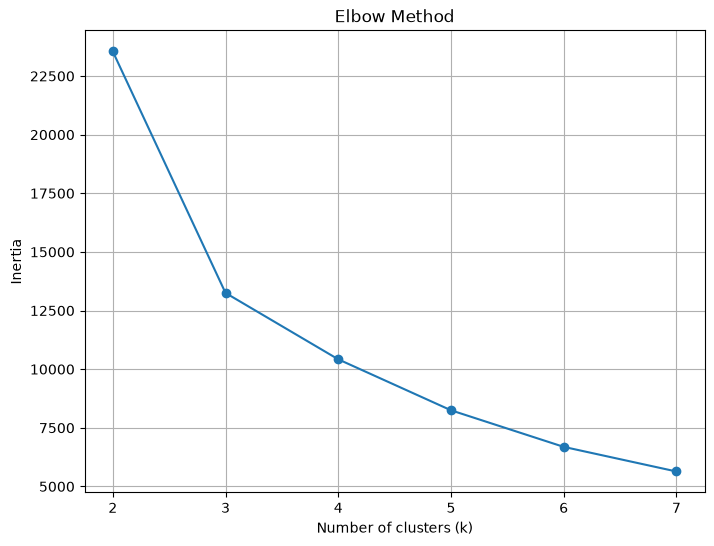

In [42]:

# ELBOW


plt.figure(figsize=(8, 6))

plt.plot(k_values, inertias, marker='o')

plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")


plt.grid()

plt.show()

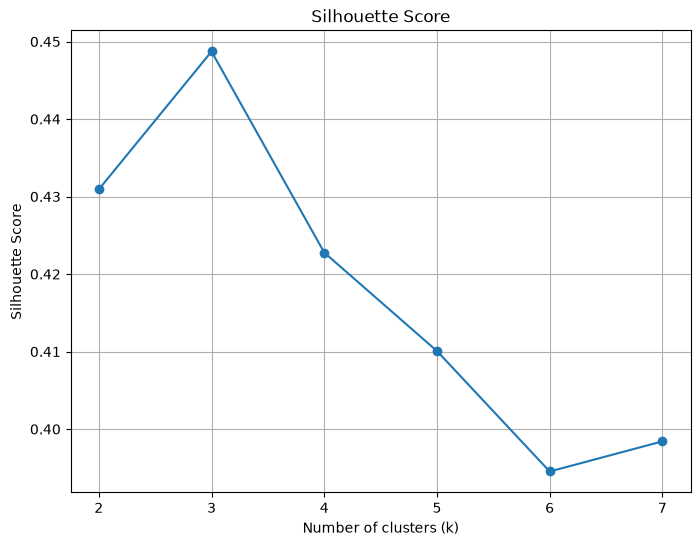

In [41]:
# SILHOUETTE

plt.figure(figsize=(8, 6))

plt.plot(k_values, silhouette_scores, marker='o')

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")


plt.grid()

plt.show()